# Thesis Part 4
## Cross-Validation: ViT + Adapters + EWC across Multiple Class Orderings

### What this notebook does:
Runs the full ViT + Adapters + EWC experiment 3 times, each time with a **different random shuffling of which classes go into which task.**

This validates that the results from Notebook 3 are not specific to one particular class ordering,
and allows reporting **mean ± std** across runs which is the standard reporting format in CL papers.

### Why class ordering matters:
Some class groupings may be easier or harder to learn sequentially depending on visual similarity.
For example, if Task 1 happens to contain very visually distinct classes, forgetting may be lower
simply due to lucky class assignment. Running multiple orderings controls for this.

### Seeds used: [42, 123, 7]
Each seed controls:
- The random class shuffle (which classes go into which task)
- Model weight initialisation (adapter + head)
- Fisher Information sampling in EWC
- DataLoader shuffling during training

In [ ]:
!pip install timm -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Seed and Reproducibility

In [ ]:
def set_seed(seed):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'  Seed set to {seed}')

## Data Loading
Load full CIFAR-100 once. Task splits are created fresh for each run with a different class ordering.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset = datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

NUM_TASKS        = 5
CLASSES_PER_TASK = 100 // NUM_TASKS  # 20

def create_tasks_from_ordering(dataset, class_ordering):
    """
    Build task splits from a specific class ordering.
    class_ordering: a shuffled list of all 100 class indices.
    Task t gets classes class_ordering[t*20 : (t+1)*20]
    """
    tasks = []
    classes_per_task = []
    targets = np.array(dataset.targets)
    for i in range(NUM_TASKS):
        class_range = class_ordering[i * CLASSES_PER_TASK : (i + 1) * CLASSES_PER_TASK]
        idx = np.isin(targets, class_range).nonzero()[0]
        tasks.append(Subset(dataset, idx))
        classes_per_task.append(class_range)
    return tasks, classes_per_task

print(f'Dataset loaded. Tasks: {NUM_TASKS}, Classes per task: {CLASSES_PER_TASK}')

100%|██████████| 169M/169M [00:03<00:00, 42.4MB/s]


Dataset loaded. Tasks: 5, Classes per task: 20


## Model: Adapter Module + ViT with Frozen Backbone

In [ ]:
class AdapterModule(nn.Module):
    """
    Bottleneck adapter: LayerNorm -> Linear(d->b) -> GELU -> Linear(b->d) -> residual
    """
    def __init__(self, d_model=192, bottleneck_dim=64):
        super().__init__()
        self.norm       = nn.LayerNorm(d_model)
        self.down_proj  = nn.Linear(d_model, bottleneck_dim)
        self.activation = nn.GELU()
        self.up_proj    = nn.Linear(bottleneck_dim, d_model)
        nn.init.zeros_(self.up_proj.weight)
        nn.init.zeros_(self.up_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.down_proj(x)
        x = self.activation(x)
        x = self.up_proj(x)
        return x + residual


class ViTWithAdapters(nn.Module):
    def __init__(self, num_classes=100, bottleneck_dim=64):
        super().__init__()
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=True,
            num_classes=num_classes
        )
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.vit.head.parameters():
            param.requires_grad = True

        d_model    = self.vit.embed_dim
        num_blocks = len(self.vit.blocks)
        self.adapters = nn.ModuleList([
            AdapterModule(d_model=d_model, bottleneck_dim=bottleneck_dim)
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = self.vit._pos_embed(x)
        x = self.vit.patch_drop(x)
        x = self.vit.norm_pre(x)
        for i, block in enumerate(self.vit.blocks):
            x = block(x)
            x = self.adapters[i](x)
        x = self.vit.norm(x)
        x = self.vit.forward_head(x)
        return x

## EWC

In [ ]:
class EWC:
    def __init__(self, model, dataset, device, n_samples=500):
        self.device = device
        self.params = {}
        self.fisher = {}

        for name, param in model.named_parameters():
            if param.requires_grad:
                self.params[name] = param.data.clone()

        self._compute_fisher(model, dataset, n_samples)

    def _compute_fisher(self, model, dataset, n_samples):
        model.eval()
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.fisher[name] = torch.zeros_like(param.data)

        indices   = torch.randperm(len(dataset))[:n_samples]
        subset    = Subset(dataset, indices)
        loader    = DataLoader(subset, batch_size=32, shuffle=False)
        criterion = nn.CrossEntropyLoss()
        n_batches = 0

        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)
            model.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            for name, param in model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    self.fisher[name] += param.grad.data.clone() ** 2
            n_batches += 1

        for name in self.fisher:
            self.fisher[name] /= n_batches

    def penalty(self, model):
        loss = torch.tensor(0.0, device=self.device)
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.fisher:
                fisher_val = self.fisher[name].to(self.device)
                anchor     = self.params[name].to(self.device)
                loss      += (fisher_val * (param - anchor) ** 2).sum()
        return loss

## Training and Evaluation Functions

In [ ]:
EWC_LAMBDA = 1000

def train_with_ewc(model, train_data, ewc_list, epochs=10, lr=1e-3):
    model.train()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer  = optim.Adam(trainable_params, lr=lr)
    criterion  = nn.CrossEntropyLoss()
    dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)

    for epoch in range(epochs):
        running_task_loss = 0.0
        running_ewc_loss  = 0.0
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs   = model(images)
            task_loss = criterion(outputs, labels)
            ewc_loss  = torch.tensor(0.0, device=device)
            for ewc in ewc_list:
                ewc_loss += EWC_LAMBDA / 2 * ewc.penalty(model)
            total_loss = task_loss + ewc_loss
            total_loss.backward()
            optimizer.step()
            running_task_loss += task_loss.item()
            running_ewc_loss  += ewc_loss.item()
        n = len(dataloader)
        print(f'    Epoch {epoch+1}/{epochs} — '
              f'Task: {running_task_loss/n:.4f} | '
              f'EWC: {running_ewc_loss/n:.4f} | '
              f'Total: {(running_task_loss+running_ewc_loss)/n:.4f}')


def evaluate_task(model, task_data, task_classes):
    model.eval()
    correct, total = 0, 0
    dataloader = DataLoader(task_data, batch_size=64, num_workers=2)
    # Vectorised label mapping
    label_map = torch.full((100,), -1, dtype=torch.long)
    for local_idx, global_idx in enumerate(task_classes):
        label_map[global_idx] = local_idx
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs      = model(images)
            outputs_task = outputs[:, task_classes]
            labels_local = label_map[labels.cpu()].to(device)
            _, preds = torch.max(outputs_task, 1)
            correct += (preds == labels_local).sum().item()
            total   += labels.size(0)
    return correct / total * 100


def evaluate_all_tasks(model, test_tasks, classes_per_task, num_seen):
    return [
        evaluate_task(model, test_tasks[t], classes_per_task[t])
        for t in range(num_seen)
    ]


def compute_metrics(acc_matrix):
    T    = len(acc_matrix)
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]
    avg_acc   = np.nanmean(full[T - 1])
    forgetting = [np.nanmax(full[:, i]) - full[T-1][i] for i in range(T - 1)]
    f_avg     = np.mean(forgetting)
    bwt       = np.mean([full[T-1][i] - full[i][i] for i in range(T - 1)])
    return avg_acc, f_avg, bwt, forgetting

## Cross-Validation Loop

For each seed:
1. Fix seed → shuffle class ordering → build task splits
2. Initialise fresh model
3. Train with EWC across all 5 tasks
4. Record metrics



In [ ]:
SEEDS = [42, 123, 7]

# Store results across runs
all_avg_acc    = []
all_f_avg      = []
all_bwt        = []
all_forgetting = []   # per-task forgetting per run
all_acc_matrices = []

for run_idx, seed in enumerate(SEEDS):
    print(f'\n' + '='*60)
    print(f'RUN {run_idx + 1}/{len(SEEDS)}  |  Seed: {seed}')
    print('='*60)

    # Step 1: Fix seed and create shuffled class ordering
    set_seed(seed)
    class_ordering = list(range(100))
    random.shuffle(class_ordering)
    print(f'  Class ordering (first 20): {class_ordering[:20]}')

    # Step 2: Build task splits from this ordering
    train_tasks, classes_per_task = create_tasks_from_ordering(train_dataset, class_ordering)
    test_tasks,  _                = create_tasks_from_ordering(test_dataset,  class_ordering)

    # Step 3: Initialise fresh model
    model    = ViTWithAdapters(num_classes=100, bottleneck_dim=64).to(device)
    ewc_list = []
    acc_matrix = []

    # Step 4: Train across all tasks
    for t_id in range(NUM_TASKS):
        print(f'\n  --- Task {t_id + 1}/{NUM_TASKS} | EWC constraints: {len(ewc_list)} ---')

        train_with_ewc(model, train_tasks[t_id], ewc_list, epochs=10, lr=1e-3)

        accs = evaluate_all_tasks(model, test_tasks, classes_per_task, num_seen=t_id + 1)
        acc_matrix.append(accs)
        print(f'  Accuracies: {[f"{a:.2f}" for a in accs]}')

        # Compute and store EWC for this task
        ewc = EWC(model, train_tasks[t_id], device, n_samples=500)
        ewc_list.append(ewc)

    # Step 5: Compute metrics for this run
    avg_acc, f_avg, bwt, forgetting = compute_metrics(acc_matrix)
    all_avg_acc.append(avg_acc)
    all_f_avg.append(f_avg)
    all_bwt.append(bwt)
    all_forgetting.append(forgetting)
    all_acc_matrices.append(acc_matrix)

    print(f'\n  === Run {run_idx + 1} Results ===')
    print(f'  Average Accuracy  : {avg_acc:.2f}%')
    print(f'  Average Forgetting: {f_avg:.2f}%')
    print(f'  Backward Transfer : {bwt:.2f}%')
    print(f'  Per-task Forgetting: {[f"{f:.2f}" for f in forgetting]}')

print('\n' + '='*60)
print('ALL RUNS COMPLETE')
print('='*60)


RUN 1/3  |  Seed: 42
  Seed set to 42
  Class ordering (first 20): [42, 41, 91, 9, 65, 50, 1, 70, 15, 78, 73, 10, 55, 56, 72, 45, 48, 92, 76, 37]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


  --- Task 1/5 | EWC constraints: 0 ---
    Epoch 1/10 — Task: 0.7560 | EWC: 0.0000 | Total: 0.7560
    Epoch 2/10 — Task: 0.1996 | EWC: 0.0000 | Total: 0.1996
    Epoch 3/10 — Task: 0.0968 | EWC: 0.0000 | Total: 0.0968
    Epoch 4/10 — Task: 0.0654 | EWC: 0.0000 | Total: 0.0654
    Epoch 5/10 — Task: 0.0463 | EWC: 0.0000 | Total: 0.0463
    Epoch 6/10 — Task: 0.0394 | EWC: 0.0000 | Total: 0.0394
    Epoch 7/10 — Task: 0.0334 | EWC: 0.0000 | Total: 0.0334
    Epoch 8/10 — Task: 0.0517 | EWC: 0.0000 | Total: 0.0517
    Epoch 9/10 — Task: 0.0447 | EWC: 0.0000 | Total: 0.0447
    Epoch 10/10 — Task: 0.0215 | EWC: 0.0000 | Total: 0.0215
  Accuracies: ['91.45']

  --- Task 2/5 | EWC constraints: 1 ---
    Epoch 1/10 — Task: 0.9691 | EWC: 0.0892 | Total: 1.0583
    Epoch 2/10 — Task: 0.2742 | EWC: 0.0854 | Total: 0.3597
    Epoch 3/10 — Task: 0.1882 | EWC: 0.0894 | Total: 0.2776
    Epoch 4/10 — Task: 0.1540 | EWC: 0.1003 | Total: 0.2543
    Epoch 5/10 — Task: 0.1191 | EWC: 0.1068 | Total: 


  --- Task 1/5 | EWC constraints: 0 ---
    Epoch 1/10 — Task: 0.9554 | EWC: 0.0000 | Total: 0.9554
    Epoch 2/10 — Task: 0.2073 | EWC: 0.0000 | Total: 0.2073
    Epoch 3/10 — Task: 0.0979 | EWC: 0.0000 | Total: 0.0979
    Epoch 4/10 — Task: 0.0511 | EWC: 0.0000 | Total: 0.0511
    Epoch 5/10 — Task: 0.0263 | EWC: 0.0000 | Total: 0.0263
    Epoch 6/10 — Task: 0.0212 | EWC: 0.0000 | Total: 0.0212
    Epoch 7/10 — Task: 0.0258 | EWC: 0.0000 | Total: 0.0258
    Epoch 8/10 — Task: 0.0632 | EWC: 0.0000 | Total: 0.0632
    Epoch 9/10 — Task: 0.0455 | EWC: 0.0000 | Total: 0.0455
    Epoch 10/10 — Task: 0.0179 | EWC: 0.0000 | Total: 0.0179
  Accuracies: ['91.00']

  --- Task 2/5 | EWC constraints: 1 ---
    Epoch 1/10 — Task: 0.7429 | EWC: 0.0769 | Total: 0.8199
    Epoch 2/10 — Task: 0.1358 | EWC: 0.0661 | Total: 0.2019
    Epoch 3/10 — Task: 0.0841 | EWC: 0.0721 | Total: 0.1561
    Epoch 4/10 — Task: 0.0723 | EWC: 0.0811 | Total: 0.1534
    Epoch 5/10 — Task: 0.0479 | EWC: 0.0805 | Total: 

## Final Results: Mean ± Std Across All Runs

In [ ]:
mean_acc = np.mean(all_avg_acc)
std_acc  = np.std(all_avg_acc)
mean_f   = np.mean(all_f_avg)
std_f    = np.std(all_f_avg)
mean_bwt = np.mean(all_bwt)
std_bwt  = np.std(all_bwt)

# Per-run breakdown
print('Per-run results:')
print(f'{"Run":<8} {"Seed":<8} {"Avg Acc":>10} {"Avg Forget":>12} {"BWT":>10}')
print('-'*50)
for i, seed in enumerate(SEEDS):
    print(f'{i+1:<8} {seed:<8} {all_avg_acc[i]:>10.2f} {all_f_avg[i]:>12.2f} {all_bwt[i]:>10.2f}')

# Summary
print('\n' + '='*60)
print(f'{"Metric":<30} {"Mean":>10} {"Std":>10}')
print('='*60)
print(f'{"Average Accuracy (%)":<30} {mean_acc:>10.2f} {std_acc:>10.2f}')
print(f'{"Average Forgetting (%)":<30} {mean_f:>10.2f} {std_f:>10.2f}')
print(f'{"Backward Transfer (%)":<30} {mean_bwt:>10.2f} {std_bwt:>10.2f}')
print('='*60)
print(f'\nReportable result:')
print(f'  Avg Accuracy  : {mean_acc:.2f} ± {std_acc:.2f}%')
print(f'  Avg Forgetting: {mean_f:.2f} ± {std_f:.2f}%')
print(f'  BWT           : {mean_bwt:.2f} ± {std_bwt:.2f}%')

Per-run results:
Run      Seed        Avg Acc   Avg Forget        BWT
--------------------------------------------------
1        42            86.19         5.51      -5.51
2        123           89.39         4.18      -4.18
3        7             85.22         8.05      -8.05

Metric                               Mean        Std
Average Accuracy (%)                86.93       1.78
Average Forgetting (%)               5.91       1.61
Backward Transfer (%)               -5.91       1.61

Reportable result:
  Avg Accuracy  : 86.93 ± 1.78%
  Avg Forgetting: 5.91 ± 1.61%
  BWT           : -5.91 ± 1.61%


## Visualisation

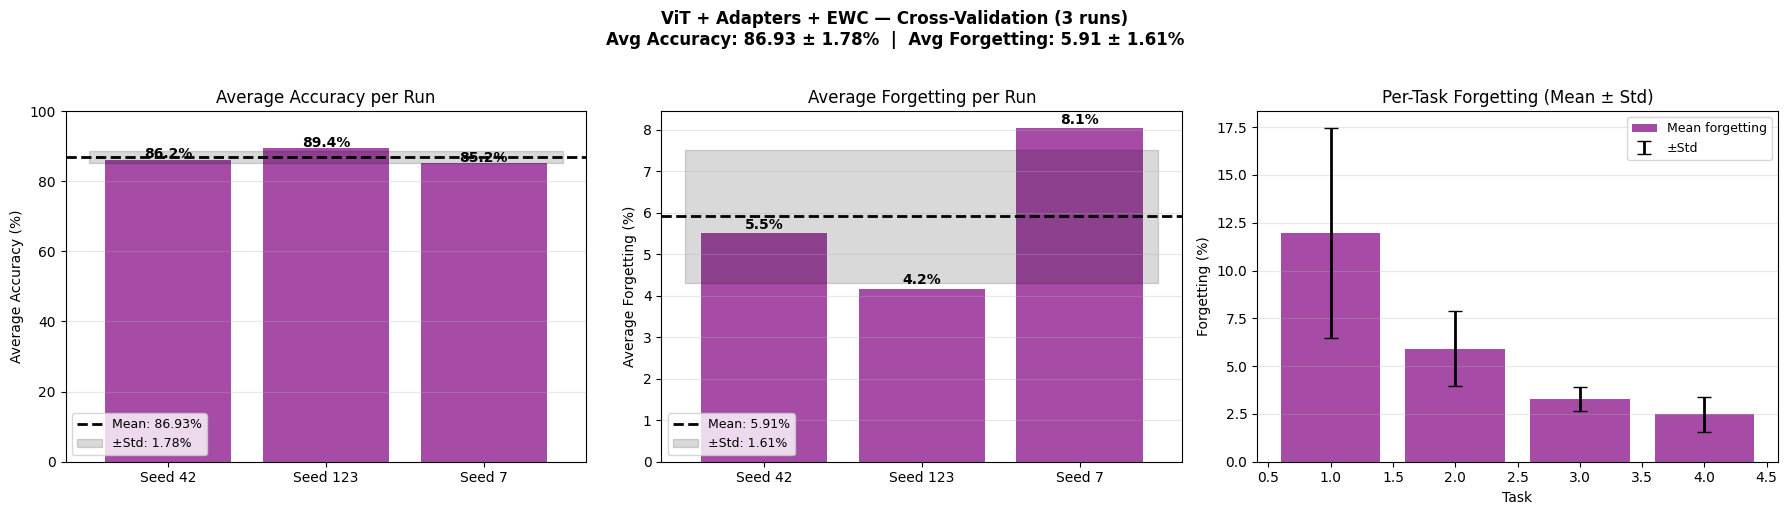

Figure saved as crossval_results.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average accuracy per run with mean line
ax = axes[0]
ax.bar(range(1, len(SEEDS)+1), all_avg_acc, color='purple', alpha=0.7)
ax.axhline(y=mean_acc, color='black', linestyle='--', linewidth=2,
           label=f'Mean: {mean_acc:.2f}%')
ax.fill_between([0.5, len(SEEDS)+0.5],
                mean_acc - std_acc, mean_acc + std_acc,
                alpha=0.15, color='black', label=f'±Std: {std_acc:.2f}%')
for i, val in enumerate(all_avg_acc):
    ax.text(i+1, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, len(SEEDS)+1))
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Average Accuracy per Run')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Average forgetting per run with mean line
ax = axes[1]
ax.bar(range(1, len(SEEDS)+1), all_f_avg, color='purple', alpha=0.7)
ax.axhline(y=mean_f, color='black', linestyle='--', linewidth=2,
           label=f'Mean: {mean_f:.2f}%')
ax.fill_between([0.5, len(SEEDS)+0.5],
                mean_f - std_f, mean_f + std_f,
                alpha=0.15, color='black', label=f'±Std: {std_f:.2f}%')
for i, val in enumerate(all_f_avg):
    ax.text(i+1, val + 0.1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, len(SEEDS)+1))
ax.set_xticklabels([f'Seed {s}' for s in SEEDS])
ax.set_ylabel('Average Forgetting (%)')
ax.set_title('Average Forgetting per Run')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Per-task forgetting across runs (mean + std per task)
ax = axes[2]
task_forgetting_matrix = np.array(all_forgetting)  # shape: (runs, T-1)
task_means = task_forgetting_matrix.mean(axis=0)
task_stds  = task_forgetting_matrix.std(axis=0)
x = np.arange(1, NUM_TASKS)
ax.bar(x, task_means, color='purple', alpha=0.7, label='Mean forgetting')
ax.errorbar(x, task_means, yerr=task_stds, fmt='none',
            color='black', capsize=5, linewidth=2, label='±Std')
ax.set_xlabel('Task')
ax.set_ylabel('Forgetting (%)')
ax.set_title('Per-Task Forgetting (Mean ± Std)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'ViT + Adapters + EWC — Cross-Validation ({len(SEEDS)} runs)\n'
             f'Avg Accuracy: {mean_acc:.2f} ± {std_acc:.2f}%  |  '
             f'Avg Forgetting: {mean_f:.2f} ± {std_f:.2f}%',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('crossval_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as crossval_results.png')